In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/train.csv")

df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [4]:
df['date'] = pd.to_datetime('2018-01-01') + \
             pd.to_timedelta(df['week'] * 7, unit='D')

# Time Features
df['month'] = df['date'].dt.month
df['weekofyear'] = df['date'].dt.isocalendar().week
df['dayofweek'] = df['date'].dt.dayofweek

# Lag Features
df = df.sort_values(by=['meal_id', 'week'])

df['lag_1'] = df.groupby('meal_id')['num_orders'].shift(1)
df['lag_2'] = df.groupby('meal_id')['num_orders'].shift(2)

# Rolling Features
df['rolling_mean_3'] = df.groupby('meal_id')['num_orders'] \
                         .transform(lambda x: x.shift(1).rolling(3).mean())

# Drop Nulls
df.dropna(inplace=True)

df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,date,month,weekofyear,dayofweek,lag_1,lag_2,rolling_mean_3
125,1231510,1,83,1062,170.78,170.78,0,0,284,2018-01-08,1,2,0,798.0,514.0,567.666667
164,1402151,1,32,1062,175.60,174.60,0,0,256,2018-01-08,1,2,0,284.0,798.0,532.000000
201,1217794,1,13,1062,185.33,185.33,0,0,998,2018-01-08,1,2,0,256.0,284.0,446.000000
246,1087222,1,109,1062,183.36,182.36,0,0,393,2018-01-08,1,2,0,998.0,256.0,512.666667
287,1483927,1,52,1062,184.33,184.33,0,0,485,2018-01-08,1,2,0,393.0,998.0,549.000000


In [5]:
features = [
    'checkout_price',
    'base_price',
    'emailer_for_promotion',
    'homepage_featured',
    'month',
    'weekofyear',
    'dayofweek',
    'lag_1',
    'lag_2',
    'rolling_mean_3'
]

target = 'num_orders'

X = df[features]
y = df[target]

In [6]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (365116, 10)
Test Shape: (91279, 10)


In [7]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    device='cuda',
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [8]:
predictions = model.predict(X_test)

predictions[:10]

c:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 3 - May\AI-Demand-Forecasting-and-Inventory-Optimization\venv\lib\site-packages\xgboost\core.py:751: UserWarning: [05:05:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


array([170.9877  , 178.1913  ,  96.18057 , 121.94621 , 116.75392 ,
       140.89508 ,  78.934326,  74.50372 ,  90.87511 , 165.25302 ],
      dtype=float32)

In [9]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 147.8820037841797
Root Mean Squared Error: 243.3607147836314


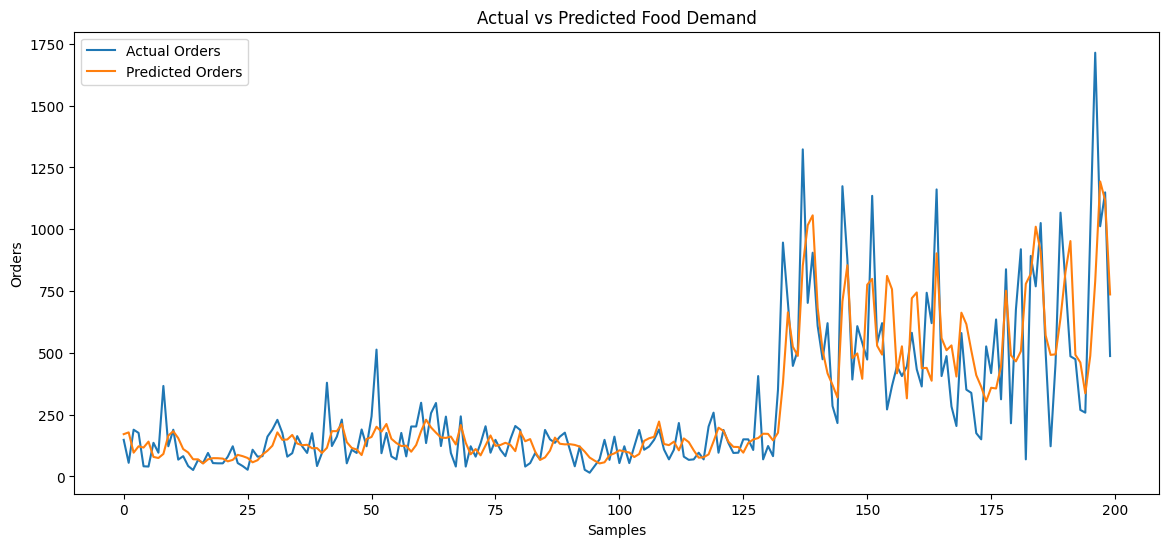

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label='Actual Orders'
)

plt.plot(
    predictions[:200],
    label='Predicted Orders'
)

plt.title("Actual vs Predicted Food Demand")

plt.xlabel("Samples")
plt.ylabel("Orders")

plt.legend()

# Save Plot
plt.savefig("../outputs/plots/actual_vs_predicted.png")

plt.show()

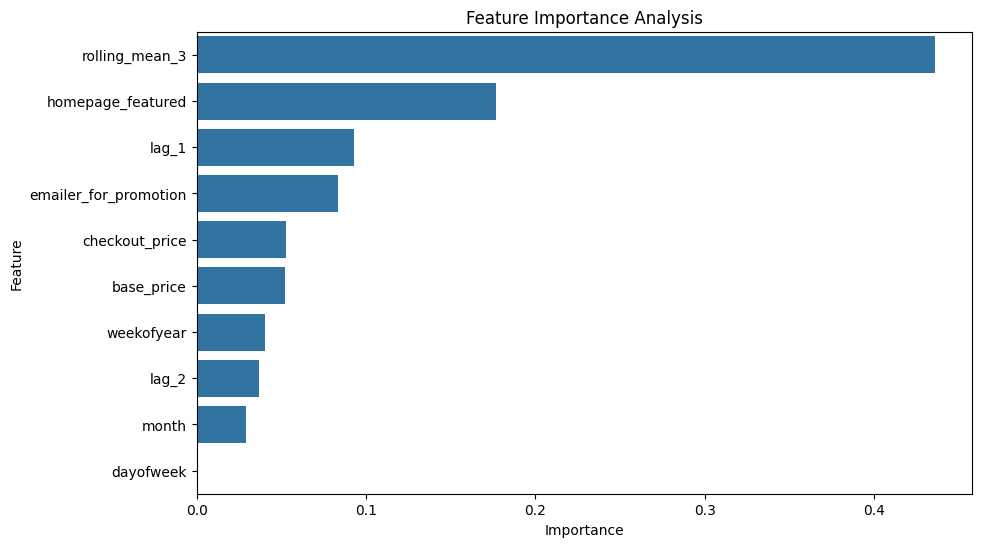

In [11]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance Analysis")

# Save Plot
plt.savefig("../outputs/plots/feature_importance.png")

plt.show()